# Evaluación de la Optimización Clásica mediante Evolución Diferencial (10D)

El presente documento desarrolla la experimentación computacional del paradigma de optimización clásico sobre el modelo cinemático reducido a 10 dimensiones ($N=6$). Se implementa el algoritmo de Evolución Diferencial. El objetivo es consolidar una distribución estadística de los óptimos alcanzados y establecer la comparativa de dispersión y convergencia frente al punto de referencia provisto por la simulación del recocido cuántico.


In [ ]:
import numpy as np
import numba
from math import sin, tan, sqrt, pow, asin, atanh, log, exp, pi, nan
import os

# Importación de la función de costo continua desde el modelo base
from 1_modelos_base.modelo_fisico_A320 import phi

## 1. Extracción del punto de referencia cuántico

Se extrae el valor óptimo reportado por la evaluación del modelo QUBO análogo. Este valor actúa como el punto de referencia o *benchmark* contra el cual se contrasta la calidad y estabilidad de las soluciones clásicas.

In [5]:
ruta_archivo_optimo = '4_optimizacion_y_resultados/optimo_qc.txt'
best_quantum_solution_energy_10d = 0.0

if os.path.exists(ruta_archivo_optimo):
    with open(ruta_archivo_optimo, 'r') as f:
        contenido_qc = f.read()
        print("Lectura del benchmark cuántico:")
        print(contenido_qc)

        if contenido_qc.strip():
            valor_texto = contenido_qc.split(':')[-1].replace('kg', '').strip()
            best_quantum_solution_energy_10d = float(valor_texto)
else:
    print("El archivo con el resultado óptimo omite su existencia en la ruta especificada.")

Lectura del benchmark cuántico:
Costo Físico Final (ϕ): -58936.41557552358 kg


## 2. Configuración del optimizador clásico

Se define una función envoltorio para el manejo de indefiniciones numéricas inherentes a las fronteras del dominio cinemático. Posteriormente, se establecen los límites operativos de la envolvente de vuelo y se inicializa el vector de referencia cinemática $\mathbf{x}_0$.

In [ ]:
# Función envoltorio para restricción de dominio
def funcion_objetivo_evolutiva(x):
    resultado = phi(*x)
    if np.isnan(resultado):
        return np.inf
    return resultado

# Semilla Inicial (x0) - 5 velocidades (v) y 5 ángulos (gamma)
x0 = np.array([
    216.22761451754096, 236.5312873424021, 231.9137085415197, 236.6251053513064, 193.17913052250347,
    2.247545371475532,  6.882037155247668, 1.3207406669454436, 1.9117623858248662, 8.529529445295587
])

# Límites de búsqueda (bounds)
limites_v = [(115.0, 242.07)] * 5
limites_gamma = [(0.0, 90.0)] * 5
limites = limites_v + limites_gamma

# Variables operativas del bucle
NUM_EJECUCIONES = 15000
BINS = 70
resultados_optimos = []

## 3. Ejecución iterativa de la búsqueda heurística

Se implementa un ciclo automatizado para la ejecución en bloque del optimizador. El algoritmo incorpora un mecanismo de perturbación gaussiana asimétrica y acotamiento estricto (`clipping`) sobre las variables de estado. Se establece un límite de evolución condicionado para forzar la re-inicialización del vector de búsqueda, mitigando el estancamiento permanente en mínimos locales aislados.

In [ ]:
from scipy.optimize import differential_evolution

x0_original = x0.copy()
a_limite = 15
contador_a = 0

for i in range(NUM_EJECUCIONES):

    resultado_optimizacion = differential_evolution(
        func=funcion_objetivo_evolutiva,
        bounds=limites,
        strategy='best1bin',
        maxiter=100,
        popsize=60,
        recombination=0.7,
        tol=1e-4,
        x0=x0,
        disp=False,
        mutation=(0.00001, 0.001),
        polish=False,
        updating='deferred',
        init='random'
    )

    if np.isfinite(resultado_optimizacion.fun):
        ruido = np.concatenate((np.random.uniform(-2e-7, 2e-7, 5), np.random.uniform(-3e-8, 3e-8, 5)))
        # 2. Cálculo de nueva semilla candidata
        nueva_x0 = resultado_optimizacion.x + ruido

        # 3. Restricción a los límites operacionales
        mins = [b[0] for b in limites]
        maxs = [b[1] for b in limites]
        x0 = np.clip(nueva_x0, mins, maxs)

        # 4. Actualización de contador y almacenamiento condicionado
        contador_a += 1
        if contador_a >= a_limite:
            resultados_optimos.append(resultado_optimizacion.fun)
            x0 = x0_original.copy()
            contador_a = 0

## 4. Análisis estadístico y visualización

Se consolida la distribución estadística de las convergencias clásicas frente al punto cuántico. La representación incluye los descriptores estadísticos fundamentales de la muestra algorítmica.

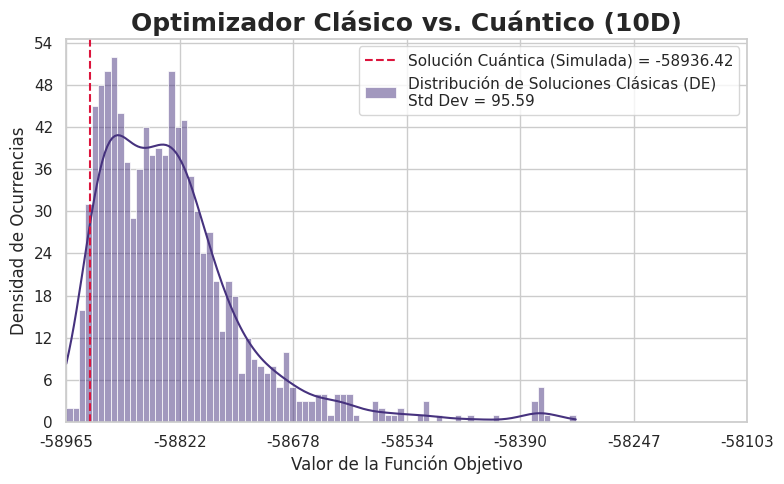

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Verificación de datos antes de graficar
if len(resultados_optimos) > 0:

    # Consolidación de límites estadísticos para la gráfica
    r_min_dyn = min(best_quantum_solution_energy_10d - 11, min(resultados_optimos))
    r_max_dyn = np.mean(resultados_optimos) + 728

    # Configuración del entorno gráfico
    sns.set_theme(style="whitegrid", palette="viridis")
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(resultados_optimos, bins=80, kde=True, ax=ax,
                 label=f'Distribución de Soluciones Clásicas (DE)\nStd Dev = {np.std(resultados_optimos):.2f}')

    # Delimitación del punto de referencia cuántico
    ax.axvline(best_quantum_solution_energy_10d, color='crimson', linestyle='--',
                label=f'Solución Cuántica (Simulada) = {best_quantum_solution_energy_10d:.2f}')

    # Atributos formales del gráfico
    ax.set_title('Optimizador Clásico vs. Cuántico (10D)', fontsize=18, weight='bold')
    ax.set_xlabel('Valor de la Función Objetivo')
    ax.set_ylabel('Densidad de Ocurrencias')
    ax.legend(loc='upper right')
    ax.set_xlim(r_min_dyn, r_max_dyn)

    # Formateo de ejes a notación entera para mayor claridad visual
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6, integer=True))
    ax.set_xticks(np.linspace(r_min_dyn, r_max_dyn, 7))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x)}"))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{int(y)}"))

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron resultados válidos en la ejecución para generar la gráfica.")